In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers, Model

In [2]:
notebook_path = Path.cwd()
base_path = notebook_path.parents[1]

raw_path = base_path / "data" / "raw" 
processed_path = base_path / "data" / "processed" 
plot_path = base_path / "fig"

In [3]:
def load_and_merge(file_abundance, file_toc, file_grain):
    df1 = pd.read_csv(raw_path / file_abundance, sep = ";")
    df2 = pd.read_csv(raw_path / file_toc, sep = ";")
    df3 = pd.read_csv(processed_path / file_grain, sep = ",")

    df4 = df1.groupby(['site', 'replicate', 'year', 'month', 'sample']).agg(
        abundance=('prawn_id', 'count'),
        biomass=('dry_weight(g)', 'sum')
    ).reset_index()

    df2["organic_matter"] = df2["dry_weight"] - df2["ash_weight"]

    df = df4.merge(df2, on=["year", "month", "site", "replicate", "sample"])
    df = df.merge(df3, on=["year", "month", "site", "replicate"])

    df["year_month"] = pd.to_datetime(
        df["month"] + " " + df["year"].astype(str)
    ).dt.to_period("M")

    df["month"] = pd.to_datetime(df["month"].str.title(), format="%B").dt.month

    return df

In [4]:
TIMESTEPS = 11
MISSING_VALUE = 0.0

In [5]:
def add_time_features(df):
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    return df

In [6]:
def prepare_tensor(df, feature_cols):
    X = []
    meta = []

    target_months = pd.period_range("2025-05", "2026-03", freq="M")

    groups = df.groupby(["site", "replicate"])

    for (site, replicate), g in groups:
        g = g.set_index("year_month").sort_index()

        # keep exactly the selected 10 months
        g = g.reindex(target_months)

        # fill missing feature values
        g[feature_cols] = g[feature_cols].fillna(MISSING_VALUE)

        X.append(g[feature_cols].values)

        for ym in target_months:
            meta.append([site, replicate, ym])

    meta = pd.DataFrame(
        meta,
        columns=["site", "replicate", "year_month"]
    )

    return np.array(X), meta

In [7]:
def create_mask(X):
    return (X != MISSING_VALUE).astype(np.float32)

def random_mask(X, missing_rate=0.2):
    mask = (np.random.rand(*X.shape) > missing_rate).astype(np.float32)
    return X * mask, mask

In [8]:
def build_model(timesteps, n_features):
    
    inputs = layers.Input(shape=(timesteps, n_features))
    
    x = layers.Masking(mask_value=MISSING_VALUE)(inputs)
    
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=False))(x)
    
    latent = layers.Dense(32, activation='relu')(x)
    
    x = layers.RepeatVector(timesteps)(latent)
    
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
    
    outputs = layers.TimeDistributed(layers.Dense(n_features))(x)
    
    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    
    return model

In [9]:
def train_model(model, X, epochs=100, batch_size=16):
    
    X_corrupt, _ = random_mask(X)
    
    model.fit(
        X_corrupt,
        X,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        verbose=0
    )

In [10]:
def impute(model, X):
    mask = create_mask(X)
    X_pred = model.predict(X)
    X_filled = mask * X + (1 - mask) * X_pred
    return X_filled

In [11]:
# MAIN PIPELINE

def run_pipeline(file_abundance, file_toc, file_grain):
    
    df = load_and_merge(file_abundance, file_toc , file_grain)
    df = add_time_features(df)
    
    grain_cols = [col for col in df.columns if "sieve" in col.lower()]
    
    feature_cols = [
        "abundance",
        "biomass",
        "organic_matter",
        *grain_cols,
        "month_sin", "month_cos"
    ]
    
    df[feature_cols] = df[feature_cols].fillna(MISSING_VALUE)
    
    X, meta = prepare_tensor(df, feature_cols)
    
    model = build_model(TIMESTEPS, X.shape[-1])
    
    train_model(model, X)
    
    X_filled = impute(model, X)
    
    return model, X_filled, meta, feature_cols

In [12]:
# Pipeline USAGE

model, X_filled, meta, feature_cols = run_pipeline(
    "abundance_biomass.csv",
    "toc.csv",
    "seive_percentage.csv"
)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7220\436383827.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["year_month"] = pd.to_datetime(


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [13]:
X_flat = X_filled.reshape(-1, X_filled.shape[-1])

df_sim = pd.concat(
    [
        meta.reset_index(drop=True),
        pd.DataFrame(X_flat, columns=feature_cols)
    ],
    axis=1
)

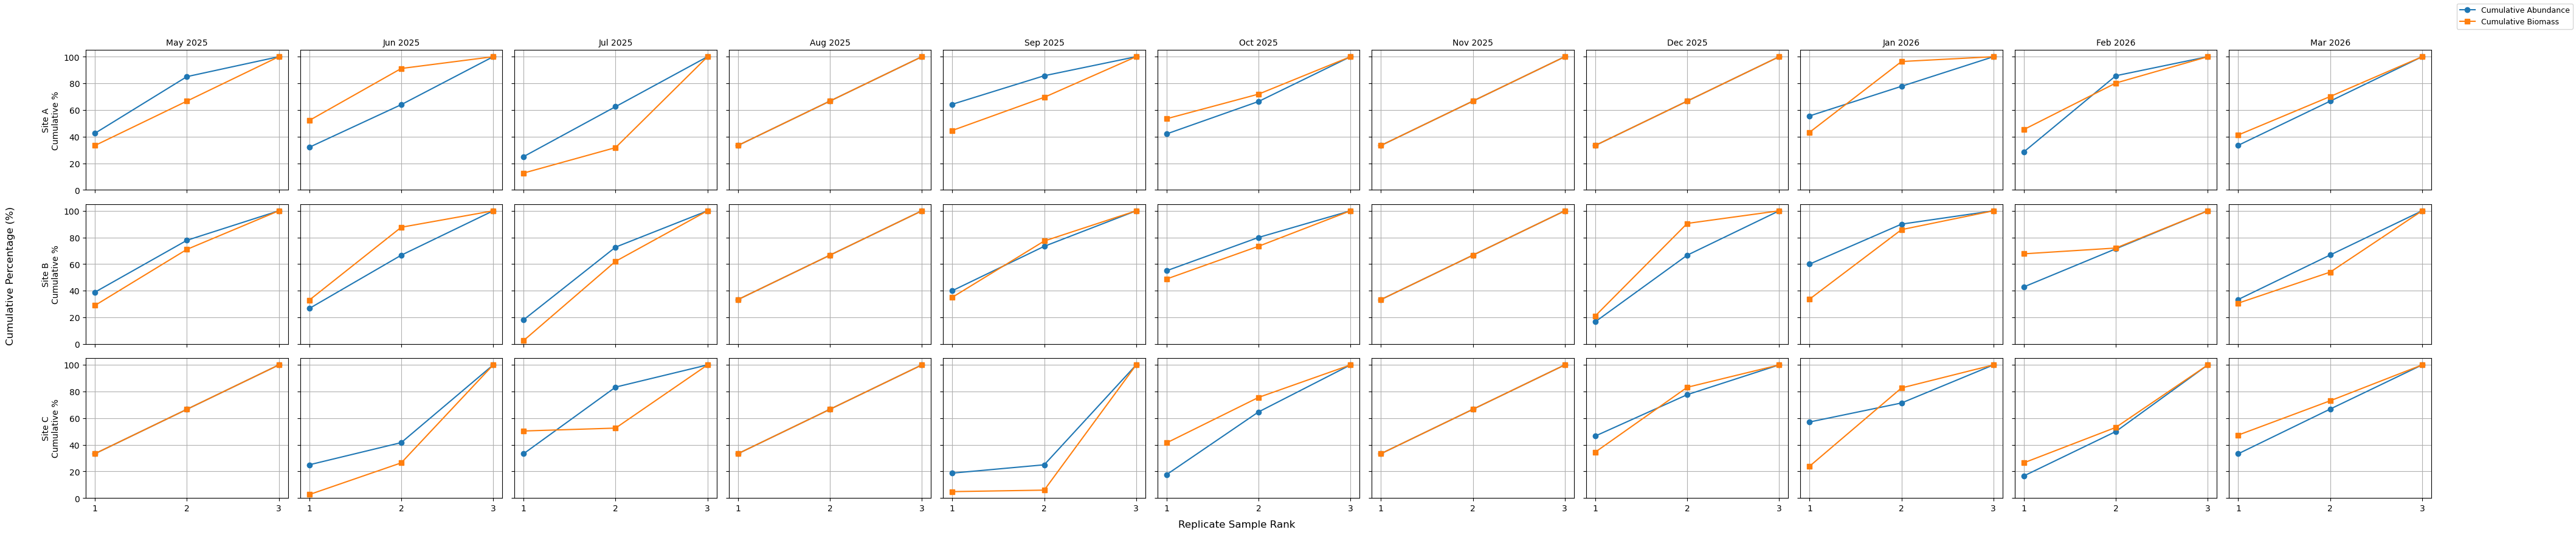

In [20]:
# --- Unique sites and months ---
sites = sorted(df_sim['site'].unique())
months = pd.period_range("2025-05", "2026-03", freq="M")# sorted(df_sim["year_month"].unique())
n_sites = len(sites)
n_months = len(months)

# --- Create subplot grid ---
fig, axes = plt.subplots(n_sites, n_months, figsize=(4*n_months, 3*n_sites), sharex=True, sharey=True)

# Ensure axes is 2D
if n_sites == 1:
    axes = axes[np.newaxis, :]
if n_months == 1:
    axes = axes[:, np.newaxis]

# --- Loop over site and month ---
for i, site in enumerate(sites):
    for j, month in enumerate(months):
        ax = axes[i, j]
        subset = df_sim[
            (df_sim['site'] == site) &
            (df_sim['year_month'] == month)
        ].sort_values(by='replicate', ascending=False)

        if subset.empty:
            ax.text(0.5, 0.5, 'No Data', ha='center', va='center', fontsize=9, color='gray')
            ax.axis('off')
            continue

        # --- Cumulative percentages ---
        subset['cum_abundance'] = subset['abundance'].cumsum() / subset['abundance'].sum() * 100
        subset['cum_biomass'] = subset['biomass'].cumsum() / subset['biomass'].sum() * 100

        # --- Plot ABC curve ---
        ax.plot(range(1, len(subset) + 1), subset['cum_abundance'], marker='o', label='Cumulative Abundance')
        ax.plot(range(1, len(subset) + 1), subset['cum_biomass'], marker='s', label='Cumulative Biomass')

        # --- Titles & labels ---
        if i == 0:
            ax.set_title(month.strftime("%b %Y"), fontsize=10)
        if j == 0:
            ax.set_ylabel(f'Site {site}\nCumulative %')

        ax.grid(True)
        ax.set_xticks(range(1, len(subset) + 1))
        ax.set_ylim(0, 105)

# --- Shared labels and legend ---
fig.text(0.5, 0.04, 'Replicate Sample Rank', ha='center', fontsize=12)
fig.text(0.04, 0.5, 'Cumulative Percentage (%)', va='center', rotation='vertical', fontsize=12)
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', fontsize=9)

plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
plt.savefig(plot_path / "ABC_curve_time_series_simulation", dpi=500)
plt.show()